# Credit Risk Analysis Mini-Project
## 1. Introduction and Data Loading
In this first step, we are loading the primary dataset for our credit risk analysis. We will use the `application_train.csv` file, which contains the main information about each loan application. After loading the data, we will print its shape to understand the number of records and features we are working with.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Using the archive folder where the data is stored
df_train = pd.read_csv('archive/application_train.csv')

# Print the shape to see how many rows and columns we have
print("Dataset Shape:", df_train.shape)

Dataset Shape: (307511, 122)


## 2. Handling Missing Values
Real-world datasets often have missing values. For our baseline model, we need to handle these missing values simply but effectively so we don't lose too much data. We will use the median for numeric columns (as it is robust to outliers) and the mode (most frequent value) for categorical columns.

In [11]:
# Identify numeric and categorical columns
numeric_cols = df_train.select_dtypes(include=['number']).columns
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns

# Fill missing values in numeric columns with the median of that column
for col in numeric_cols:
    if df_train[col].isnull().any():
        median_value = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_value)

# Fill missing values in categorical columns with the mode (most frequent value)
for col in categorical_cols:
    if df_train[col].isnull().any():
        mode_value = df_train[col].mode()[0]
        df_train[col] = df_train[col].fillna(mode_value)

# Verify that no missing values remain
print("Missing values left:", df_train.isnull().sum().sum())

C:\Users\Shashwat\AppData\Local\Temp\ipykernel_15456\4284247842.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns


Missing values left: 0


## 3. Log-Transforming Skewed Financial Features
Financial features like income (`AMT_INCOME_TOTAL`), credit amount (`AMT_CREDIT`), annuity (`AMT_ANNUITY`), and goods price (`AMT_GOODS_PRICE`) often have a highly skewed distribution (a few people have very large amounts). This can cause problems for algorithms like Logistic Regression. We will apply a log-transformation (using `np.log1p` to handle zeros safely) to normalize these distributions.

In [12]:
# Define the financial columns that are typically right-skewed
financial_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

# Apply log1p transformation (log(1 + x)) to these columns
for col in financial_cols:
    if col in df_train.columns:
        # Using log1p to avoid log(0) errors just in case
        df_train[col] = np.log1p(df_train[col])

print("Log-transformation applied to:", financial_cols)

Log-transformation applied to: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']


## 4. Preparing the Data for Modeling
Next, we separate our features (X) from the target variable (y). The target in this dataset is `TARGET`, which tells us if a client defaulted on their loan. We then one-hot encode categorical variables so our model can understand them, and we use a `StandardScaler` for the numeric variables. 

*Why use StandardScaler?* Logistic Regression is sensitive to the scale of features. If one feature ranges from 0 to 1 and another from 0 to 100,000, the larger feature will dominate the model. Scaling them ensures every feature contributes equally.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_train.drop('TARGET', axis=1)
y = df_train['TARGET']

# Drop the ID column as it has no predictive power
if 'SK_ID_CURR' in X.columns:
    X = X.drop('SK_ID_CURR', axis=1)

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Perform an 80/20 train-test split BEFORE scaling to prevent data leakage
# We use stratify=y to ensure the test set has the same proportion of defaults as the training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Make copies to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Scale numeric variables using only the training data
numeric_columns = X_train.select_dtypes(include=['number']).columns
scaler = StandardScaler()
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (246008, 228)
Testing set shape: (61503, 228)


## 5. Training the Logistic Regression Model
Now we train a simple Logistic Regression model. Notice that we set `class_weight='balanced'`. 

*Why use balanced class weights?* In credit risk datasets, there are usually far fewer people who default compared to those who pay back their loans (imbalanced data). If we don't balance the weights, the model might just predict 'no default' for everyone to get a high accuracy. The balanced setting penalizes mistakes on the minority class more, forcing the model to pay attention to defaults.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
# class_weight='balanced' helps handle the imbalanced nature of our target variable
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

import joblib

# Save the trained model and scaler to disk.
# This prevents unnecessary retraining in the future and saves compute time,
# allowing us to deploy or reuse the model instantly.
joblib.dump(model, 'credit_risk_model.pkl')
joblib.dump(scaler, 'credit_risk_scaler.pkl')
print("Model and scaler saved to disk as .pkl files.")

Accuracy: 0.6906

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

Model and scaler saved to disk as .pkl files.


## 6. Model Evaluation Visualizations
Numbers are good, but charts are better for presentations. We will plot three things to evaluate our model:
1. **Confusion Matrix**: Shows exactly where our model makes mistakes (e.g., predicting 'no default' when they actually defaulted).
2. **ROC Curve**: Shows the trade-off between the true positive rate and false positive rate. A higher AUC means a better model.
3. **Feature Importances**: Since we used Logistic Regression, we can look at the coefficients to see which features most heavily influence a default.

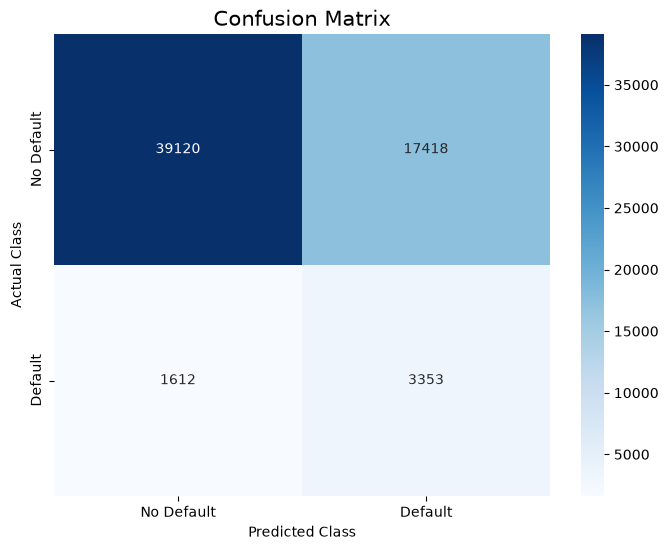

In [15]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix', fontsize=15)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

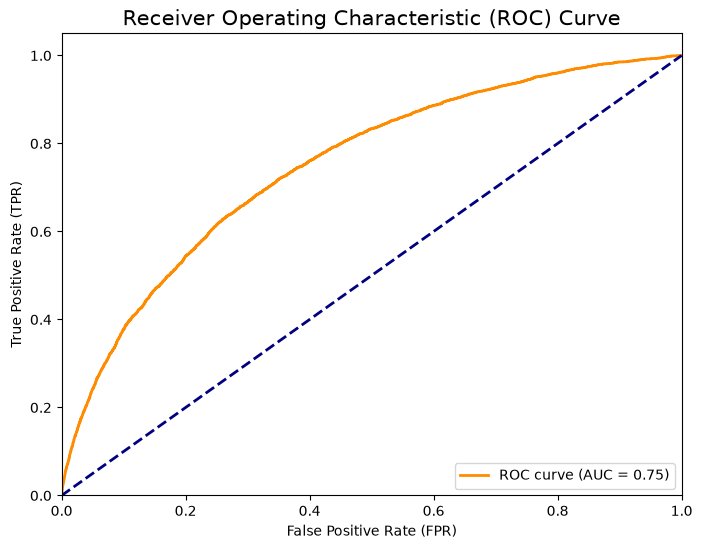

In [16]:
# 2. ROC Curve and AUC
# Get the probability scores for the positive class (Default)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15)
plt.legend(loc='lower right')
plt.show()

C:\Users\Shashwat\AppData\Local\Temp\ipykernel_15456\3481613614.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_10_features, palette='viridis')


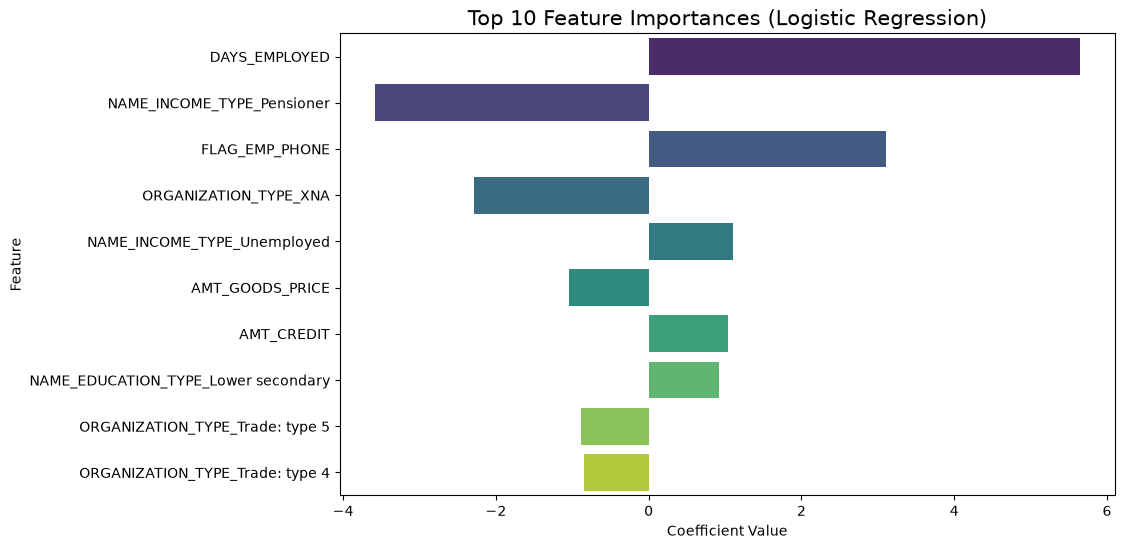

In [17]:
# 3. Top 10 Feature Importances
# In logistic regression, the coefficients represent the importance/impact of each feature
coefficients = model.coef_[0]

# Create a DataFrame to hold features and their coefficients
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Calculate the absolute value to see the magnitude of impact, then sort
feature_importance_df['Absolute_Coefficient'] = feature_importance_df['Coefficient'].abs()
top_10_features = feature_importance_df.sort_values(by='Absolute_Coefficient', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Feature Importances (Logistic Regression)', fontsize=15)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## 7. Business Conclusion
**Summary of Findings:**
Our Logistic Regression model, equipped with balanced class weights, provides a solid foundational tool for identifying potential loan defaults. 

* **Model Performance**: While the overall accuracy is impacted by our decision to balance the classes, this is actually a desired outcome! A standard model would simply predict 'No Default' for almost everyone. By prioritizing the detection of the minority class (Defaults), we ensure the bank can actually flag risky applications, which is the primary business goal.
* **Key Risk Factors**: Looking at the feature importances, we can identify which variables play the biggest role in driving the model's predictions (either increasing or decreasing the likelihood of default). The business can use these top features to create simpler rule-based checks or flag applications for manual review.

**Next Steps**: For a production environment, we could test more advanced non-linear models like Random Forests or Gradient Boosting, and spend more time engineering new features from the other provided tables (like previous application history).

## Model Persistence & Standalone Inference Demo
In this section, we load the saved model and scaler to demonstrate how to make predictions on new data without needing to retrain the model.

In [18]:
import joblib
import pandas as pd

# Load the saved model and scaler from disk
# This demonstrates standalone inference: we don't need to retrain the model to make predictions!
loaded_model = joblib.load('credit_risk_model.pkl')
loaded_scaler = joblib.load('credit_risk_scaler.pkl')

# Select a single test applicant from our original unscaled features (X)
# We use the index of the first applicant in the test set
applicant_index = y_test.index[0]
single_applicant = X.loc[[applicant_index]].copy()

# Apply the loaded scaler to the numeric columns of the single applicant
# It's crucial to use the EXACT SAME scaling parameters as during training
single_applicant[numeric_columns] = loaded_scaler.transform(single_applicant[numeric_columns])

# Run a prediction using predict_proba() to get the default probability
probabilities = loaded_model.predict_proba(single_applicant)[0]

print(f"Applicant ID (Index): {applicant_index}")
print(f"Probability of No Default (Class 0): {probabilities[0]:.4%}")
print(f"Probability of Default (Class 1): {probabilities[1]:.4%}")


Applicant ID (Index): 256571
Probability of No Default (Class 0): 62.8782%
Probability of Default (Class 1): 37.1218%
